In [1]:
import os
import torch

# Set GPU 3 only
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# Verify GPU setup
if torch.cuda.is_available():
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available - will use CPU")

CUDA available: True
Number of GPUs: 1
Current GPU: 0
GPU name: NVIDIA RTX A6000


In [2]:
# 📦 Imports
import json
from collections import Counter
from pathlib import Path
import os
import evaluate
import pandas as pd
from datasets import Dataset, DatasetDict


# 📊 Evaluation metric
from evaluate import load
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments, EarlyStoppingCallback
)

accuracy_metric = load("accuracy")


/data/literature/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/literature/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [3]:
# 📂 Dataset Paths
DATASET_DIR = Path("/home/literature/hindwi-scraper/output")
POETS_JSON = DATASET_DIR / "poets.json"

In [4]:
# 📥 Load poets.json
with open(POETS_JSON, encoding='utf-8') as f:
    poets = json.load(f)

In [5]:
# 🔄 poet_slug → poet metadata
poet_map = {poet['poet_slug']: poet for poet in poets}

In [6]:

poets_dir = DATASET_DIR / "poets"  # adjust if needed

summary = []

print("Counting poems ending with -devnagri.txt ...")

for poet_dir in tqdm([p for p in poets_dir.iterdir() if p.is_dir()]):
    poet_name = poet_dir.name
    kavita_dir = poet_dir / "kavita"

    if not kavita_dir.is_dir():
        continue

    # collect all files that end with -devnagri.txt
    devnagri_poems = [
        f for f in kavita_dir.iterdir()
        if f.is_file() and f.name.endswith("-devnagri.txt")
    ]

    summary.append({
        "poet_name": poet_name,
        "devanagari_count": len(devnagri_poems)
    })

# 📊 Per-poet DataFrame
df_summary = pd.DataFrame(summary).sort_values("devanagari_count", ascending=False)

print("\n=== Top 20 poets by Devanagari poem count ===")
print(df_summary.head(20))

# Save if needed
# df_summary.to_csv("dataset/poet_summary_filebased.csv", index=False, encoding="utf-8")


Counting poems ending with -devnagri.txt ...


  0%|          | 0/2382 [00:00<?, ?it/s]

100%|██████████| 2382/2382 [00:00<00:00, 9431.22it/s]


=== Top 20 poets by Devanagari poem count ===
                    poet_name  devanagari_count
1229              mona-gulati               113
339         pankaj-chaturvedi                87
1353      vijay-bahadur-singh                84
1492  krishna-murari-pahariya                81
1843             savita-singh                78
685               hari-mridul                75
178                     laltu                75
847              naveen-sagar                74
992       neelesh-raghuvanshi                71
1603      maithilisharan-gupt                70
1605  sheomangal-siddhantakar                70
1142                   malyaj                69
1746        sanjay-chaturvedi                67
507                    shubha                65
1021                 udbhrant                65
269              chandreshwar                62
694            krishna-kalpit                62
1181          manglesh-dabral                61
971             narendra-jain            

In [7]:

poets_dir = DATASET_DIR / "poets"
min_poems = 50

# 🔢 Count poems ending with "-devnagri.txt" for each poet
poet_counts = {}
for poet_dir in tqdm(list(poets_dir.iterdir()), desc="Counting poems"):
    if poet_dir.is_dir():
        kavita_dir = poet_dir / "kavita"
        if kavita_dir.is_dir():
            count = sum(1 for f in kavita_dir.glob("*-devnagri.txt"))
            if count > 0:
                poet_counts[poet_dir.name] = count

# 📊 Convert to DataFrame
poem_counts = pd.DataFrame(list(poet_counts.items()), columns=["poet_name", "devanagari_count"])

# 🎯 Filter poets with at least min_poems
poets_to_keep = set(poem_counts.loc[poem_counts["devanagari_count"] >= min_poems, "poet_name"])

print(f"Total poets with >= {min_poems} poems: {len(poets_to_keep)}")

# 📚 Build dataset (poet_name → poem text)
all_poems = []
for poet_dir in tqdm(list(poets_dir.iterdir()), desc="Loading poems"):
    if poet_dir.is_dir() and poet_dir.name in poets_to_keep:
        kavita_dir = poet_dir / "kavita"
        if kavita_dir.is_dir():
            for poem_file in kavita_dir.glob("*-devnagri.txt"):
                try:
                    poem_text = poem_file.read_text(encoding='utf-8').strip()
                    if poem_text:
                        all_poems.append({
                            "poet_name": poet_dir.name,
                            "poem": poem_text
                        })
                except Exception as e:
                    print(f"Error reading {poem_file}: {e}")

# 📑 Final DataFrame
df_filtered = pd.DataFrame(all_poems)

print(f"\nFinal dataset size: {len(df_filtered)} poems")
print(f"Unique poets: {df_filtered['poet_name'].nunique()}")
print("\nSample:")
print(df_filtered.head())


Counting poems: 100%|██████████| 2382/2382 [00:00<00:00, 20405.28it/s]


Total poets with >= 50 poems: 42


Loading poems: 100%|██████████| 2382/2382 [00:00<00:00, 39603.41it/s]


Final dataset size: 2451 poems
Unique poets: 41

Sample:
                   poet_name  \
0  acharya-ramchandra-shukla   
1  acharya-ramchandra-shukla   
2  acharya-ramchandra-shukla   
3  acharya-ramchandra-shukla   
4  acharya-ramchandra-shukla   

                                                poem  
0  भोले भाले देश भाइयों से जरा।\nभिन्न लगें, यह भ...  
1  भूलि गयो सब पूजा पाठ विचार\nकेवल उनकी ध्यान भय...  
2  तन में भरम रमायो त्यागी राज,\nसहन कठिन दुख कीन...  
3  पहले पहल पुकारा था जिसने जहाँ\nजिन नामों से जन...  
4  यद्यपि मैं हूँ एक अकेला, बैरी की सेना भारी।\nप...  


In [8]:
unique_poets = sorted(df_filtered["poet_name"].unique())
label2id = {poet: i for i, poet in enumerate(unique_poets)}
id2label = {i: poet for i, poet in enumerate(unique_poets)}

df_filtered["label"] = df_filtered["poet_name"].map(label2id)

# ✂️ First split: train (80%) + temp (20%) WITHOUT stratify
train_df, temp_df = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=42
)

# ✂️ Second split: temp → val (10%) + test (10%) WITHOUT stratify
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,   # half of 20% → 10%
    random_state=42
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

# Convert to Hugging Face datasets
train_ds = Dataset.from_pandas(train_df[["poem", "label"]])
val_ds   = Dataset.from_pandas(val_df[["poem", "label"]])
test_ds  = Dataset.from_pandas(test_df[["poem", "label"]])

Train size: 1960
Validation size: 245
Test size: 246


In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "ai4bharat/IndicBERTv2-MLM-only"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(unique_poets),
    id2label=id2label,
    label2id=label2id
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/IndicBERTv2-MLM-only and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
def tokenize(batch):
    return tokenizer(
        batch["poem"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

for ds in [train_ds, val_ds, test_ds]:
    ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])


Map: 100%|██████████| 246/246 [00:00<00:00, 5025.39 examples/s]


In [11]:
train_ds, train_ds.take(1).to_list()

(Dataset({
     features: ['poem', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 1960
 }),
 [{'poem': 'यह कहना ग़लत होगा कि\nमैं मकान बनवा रहा हूँ\nदरअसल सच यह है कि\nमकान मुझे बना रहा है\nअनुभवों की ईट-सरिया\nअहसासों के मसाले\nमुझे रोज़ फुट-दर-फुट ऊपर उठा रहे हैं\nबाज़ार की हवा मुझे सुखा रही है\nपूर्वजों के कष्टों का पानी सींच रहा है\nमैं हर पिछले दिन से अगले दिन\nअपने आपको अलग पा रहा हूँ\nसीमेंट जैसी प्यास चाहिए मज़बूती के लिए।\nमकान सिखा रहा है मुझे\nबातों की सरिया से भरोसे की जाल बनाना\nताकि डाल सकूँ\nभरोसे के संकट से भरे इस समय में\nमजबूत संबंधों का एक लैंटर।\nमकान बता रहा है मुझे\nएक सही अनुपात का क्या महत्व होता है जीवन में\nकितना मीठा, कितना नमकीन\nऔर कितना कसैला बोलना है काम निकालने के लिए\nमकान खोल रहा है मेरे सामने\nरेता-रोड़ी-बजरी-लकड़ी के धंधे में लगे लोगों के\nट्रकों के क़ाफ़िले में साल-दर-साल होती वृद्धि के रहस्य को\nमकान समझा रहा है मुझे\nसही-सही अंतर\nमज़दूर के पेशानी में छलक आए पसीने\nऔर रोज़ सुबह मॉर्निग वॉक पर निकले\nथुल

In [12]:

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./poet_classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,                 # Keep only the best checkpoint
    load_best_model_at_end=True,        # Reload best checkpoint at the end
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    num_train_epochs=30,                # Max, but early stopping will cut it
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=3e-5,
    weight_decay=0.05,                  # Add regularization
    warmup_ratio=0.1,
    logging_dir="./logs",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Stop if no improvement for 3 epochs
)

trainer.train()


/tmp/ipykernel_3548824/1488795819.py:27: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,3.695600,3.612251,0.102041
2,3.302000,2.926235,0.334694
3,2.646900,2.433190,0.416327
4,2.041600,1.980660,0.506122
5,1.466200,1.663677,0.587755
6,0.961700,1.455569,0.624490
7,0.564500,1.431033,0.608163
8,0.296100,1.394214,0.624490
9,0.130800,1.349355,0.640816
10,0.050700,1.349566,0.648980


TrainOutput(global_step=3675, training_loss=1.0123524158017165, metrics={'train_runtime': 484.6045, 'train_samples_per_second': 121.336, 'train_steps_per_second': 15.167, 'total_flos': 3869086859366400.0, 'train_loss': 1.0123524158017165, 'epoch': 15.0})

In [13]:
results = trainer.evaluate(test_ds)
print("📊 Test set performance:", results)


📊 Test set performance: {'eval_loss': 1.4542828798294067, 'eval_accuracy': 0.6869918699186992, 'eval_runtime': 0.8615, 'eval_samples_per_second': 285.544, 'eval_steps_per_second': 35.983, 'epoch': 15.0}


In [14]:
import numpy as np

# Use the trainer to get predictions on the tokenized validation set
print("Getting predictions from the model on the validation set...")
predictions_output = trainer.predict(test_ds)

# The output.predictions are the raw logits, so we take the argmax to get the predicted class
y_pred = np.argmax(predictions_output.predictions, axis=1)

# The true labels are also available in the output
y_true = predictions_output.label_ids

print("Predictions obtained successfully!")

Getting predictions from the model on the validation set...
Predictions obtained successfully!


In [15]:
from sklearn.metrics import classification_report

# Get the actual names of the poets using the id2label mapping from earlier
class_names = [id2label[i] for i in range(len(id2label))]

# Generate the report
print("\nClassification Report:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


Classification Report:
                           precision    recall  f1-score   support

acharya-ramchandra-shukla       0.67      1.00      0.80         4
                   agyeya       0.57      0.80      0.67         5
                baby-shaw       0.33      0.50      0.40         2
    chandrakant-devtale-1       0.75      0.67      0.71         9
             chandreshwar       0.83      0.83      0.83         6
                dafairoon       0.33      0.40      0.36         5
 dilip-purushottam-chitre       0.60      0.60      0.60         5
    hare-prakash-upadhyay       0.42      0.62      0.50         8
              hari-mridul       0.33      0.67      0.44         3
       jagdish-chaturvedi       0.67      0.75      0.71         8
             jyoti-shobha       1.00      0.50      0.67         8
     kamal-jeet-chaudhary       0.86      0.86      0.86         7
     kanhaiyalal-sethia-1       1.00      0.80      0.89         5
            keshav-tiwari       0.00 

/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/lit

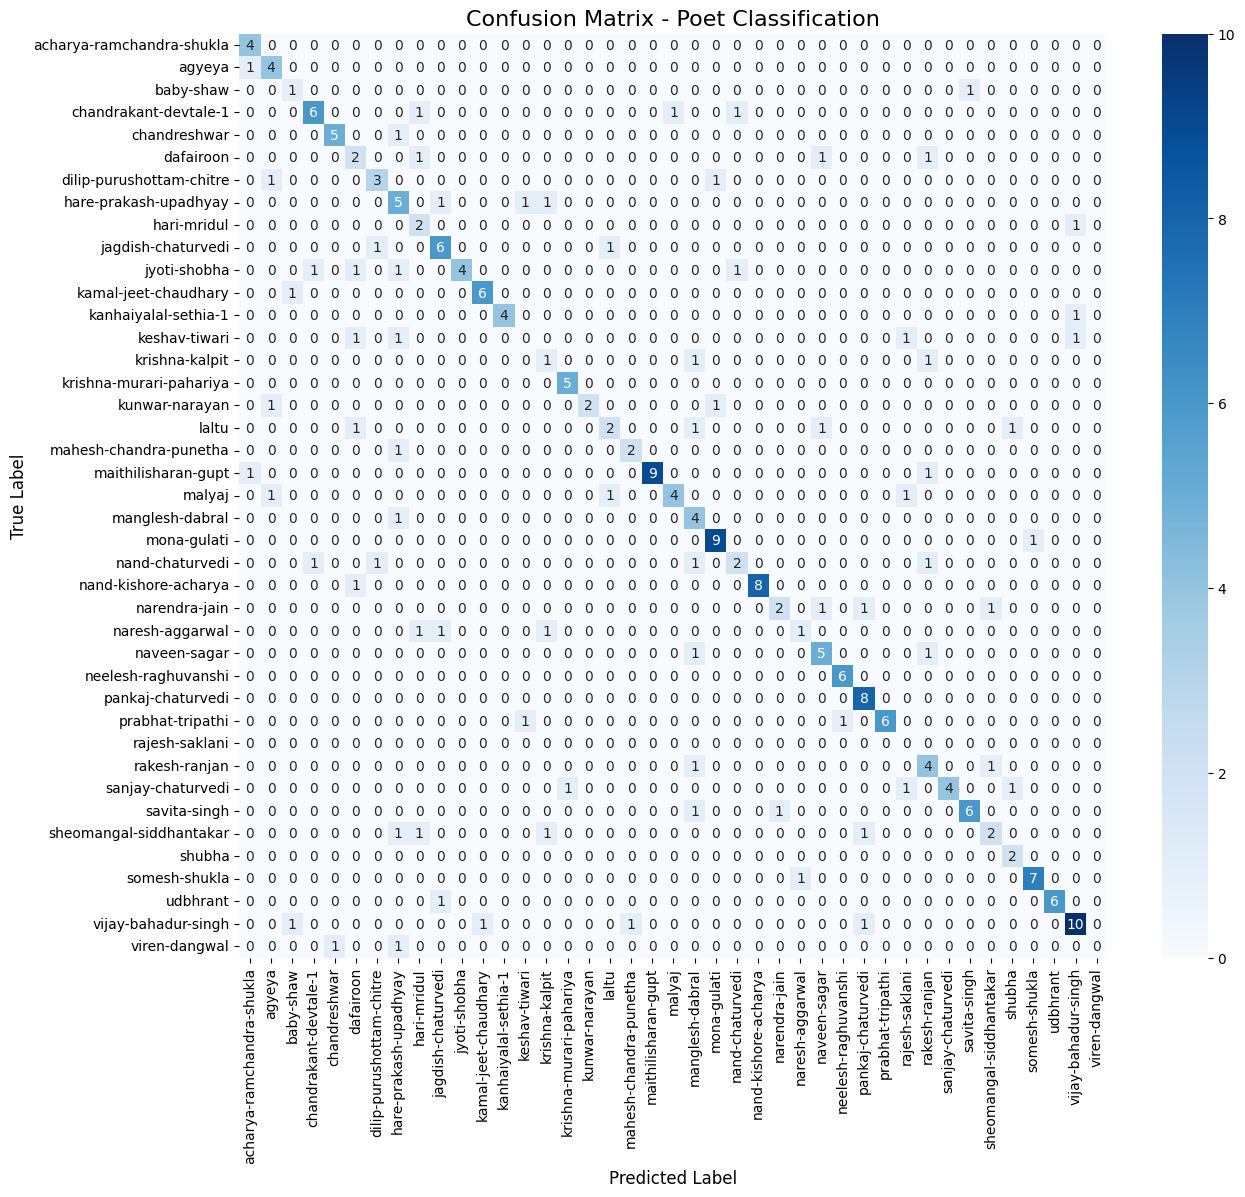

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(14, 12))  # Adjust the size as needed for your number of classes
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Poet Classification', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [17]:
# 📊 Group poems by poet
df_grouped = df_filtered.groupby("poet_name")["poem"].apply(lambda texts: " ".join(texts)).reset_index()
df_grouped.head()


,poet_name,poem
0,acharya-ramchandra-shukla,"भोले भाले देश भाइयों से जरा।\nभिन्न लगें, यह भ..."
1,agyeya,मैं मरूँगा सुखी\nक्योंकि तुमने जो जीवन दिया था...
2,baby-shaw,तुम्हें सोचते\nरच उठती है\nएक नई भाषा\nनए लक्ष...
3,chandrakant-devtale-1,ख़ामोशी में छेद करना ज़रूरी है\nइसलिए अँधेरे म...
4,chandreshwar,माँ छुपा रही थीं\nकुछ\nमन ही मन\nचुप थे पिता भ...


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 🔤 Convert poems into TF-IDF features
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000, stop_words="english")

X = vectorizer.fit_transform(df_grouped["poem"])

print("TF-IDF matrix shape:", X.shape)


TF-IDF matrix shape: (41, 5000)


In [19]:
from sklearn.decomposition import PCA

# ⚡ Reduce dimensions (cannot exceed 41 since we have 41 poets)
pca = PCA(n_components=20, random_state=42)
X_reduced = pca.fit_transform(X.toarray())

print("Reduced shape:", X_reduced.shape)


Reduced shape: (41, 20)


In [20]:
from sklearn.cluster import KMeans

# 🎯 Cluster poets into groups
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  # try 5 clusters first
clusters = kmeans.fit_predict(X_reduced)

# Add cluster labels back to dataframe
df_grouped["cluster"] = clusters
df_grouped.head()


,poet_name,poem,cluster
0,acharya-ramchandra-shukla,"भोले भाले देश भाइयों से जरा।\nभिन्न लगें, यह भ...",1
1,agyeya,मैं मरूँगा सुखी\nक्योंकि तुमने जो जीवन दिया था...,1
2,baby-shaw,तुम्हें सोचते\nरच उठती है\nएक नई भाषा\nनए लक्ष...,4
3,chandrakant-devtale-1,ख़ामोशी में छेद करना ज़रूरी है\nइसलिए अँधेरे म...,4
4,chandreshwar,माँ छुपा रही थीं\nकुछ\nमन ही मन\nचुप थे पिता भ...,0


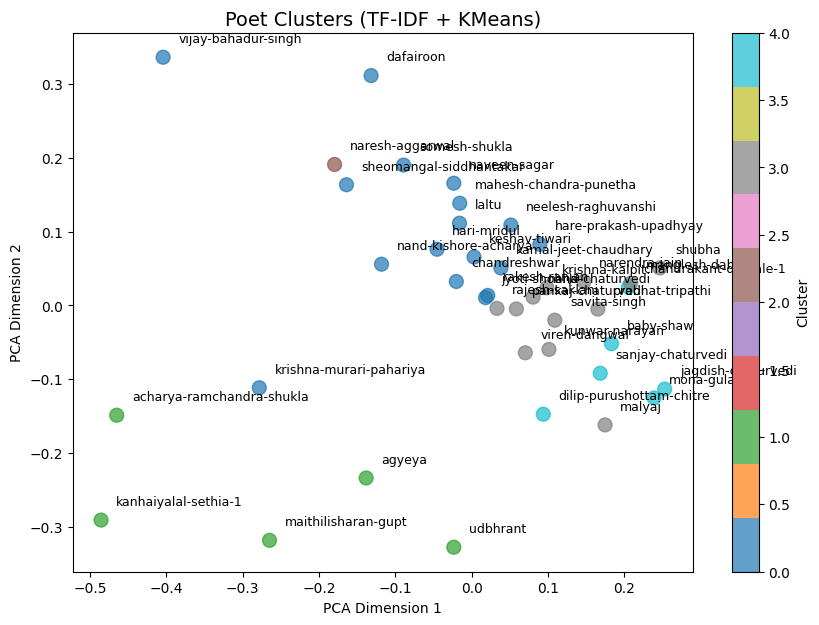

In [21]:
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X.toarray())

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, cmap="tab10", s=100, alpha=0.7)

# Annotate poet names
for i, poet in enumerate(df_grouped["poet_name"]):
    plt.annotate(poet, (X_2d[i,0]+0.02, X_2d[i,1]+0.02), fontsize=9)

plt.title("Poet Clusters (TF-IDF + KMeans)", fontsize=14)
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.colorbar(scatter, label="Cluster")
plt.show()


In [22]:
import numpy as np

# Get feature names from TF-IDF
terms = vectorizer.get_feature_names_out()

def top_words_for_cluster(X, clusters, cluster_id, n=10):
    # Mask rows belonging to this cluster
    mask = (clusters == cluster_id)
    # Average TF-IDF score across poets in this cluster
    mean_tfidf = X[mask].mean(axis=0).A1
    # Top n words
    top_indices = mean_tfidf.argsort()[::-1][:n]
    return [terms[i] for i in top_indices]

# Show top words per cluster
for cluster_id in sorted(set(clusters)):
    words = top_words_for_cluster(X, clusters, cluster_id, n=15)
    print(f"\n🔹 Cluster {cluster_id}:")
    print(", ".join(words))



🔹 Cluster 0:
रह, नह, पर, और, कर, एक, अपन, वह, कह, यह, हर, हम, इस, तन, तरह

🔹 Cluster 1:
कर, पर, नह, रह, यह, वह, और, एक, हम, अपन, रत, कह, उस, अन, वर

🔹 Cluster 2:
नह, रह, वह, पर, तरह, उसक, एक, और, कर, कह, हर, बढ, बच, हम, तक

🔹 Cluster 3:
और, एक, पर, नह, रह, वह, कर, अपन, यह, हम, उस, कह, तरह, हर, इस

🔹 Cluster 4:
और, पर, नह, एक, रह, कर, अपन, हम, हर, वह, यह, रत, इस, तरह, पत


In [23]:
# Map poet_name → cluster
poet_to_cluster = dict(zip(df_grouped["poet_name"], df_grouped["cluster"]))

# Assign each poem in df_filtered to its poet's cluster
df_filtered["cluster_label"] = df_filtered["poet_name"].map(poet_to_cluster)
df_filtered.head()


,poet_name,poem,label,cluster_label
0,acharya-ramchandra-shukla,"भोले भाले देश भाइयों से जरा।\nभिन्न लगें, यह भ...",0,1
1,acharya-ramchandra-shukla,भूलि गयो सब पूजा पाठ विचार\nकेवल उनकी ध्यान भय...,0,1
2,acharya-ramchandra-shukla,"तन में भरम रमायो त्यागी राज,\nसहन कठिन दुख कीन...",0,1
3,acharya-ramchandra-shukla,पहले पहल पुकारा था जिसने जहाँ\nजिन नामों से जन...,0,1
4,acharya-ramchandra-shukla,"यद्यपि मैं हूँ एक अकेला, बैरी की सेना भारी।\nप...",0,1


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered["poem"], df_filtered["cluster_label"], 
    test_size=0.2, random_state=42, stratify=df_filtered["cluster_label"]
)

# TF-IDF on poems (not aggregated)
vectorizer_cls = TfidfVectorizer(ngram_range=(1,2), max_features=10000, stop_words="english")
X_train_vec = vectorizer_cls.fit_transform(X_train)
X_test_vec = vectorizer_cls.transform(X_test)

# Logistic Regression classifier
clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X_train_vec, y_train)

# Evaluate
y_pred = clf.predict(X_test_vec)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.55      0.86      0.67       210
           1       0.79      0.27      0.40        56
           2       0.00      0.00      0.00        12
           3       0.53      0.47      0.50       135
           4       0.74      0.26      0.38        78

    accuracy                           0.57       491
   macro avg       0.52      0.37      0.39       491
weighted avg       0.59      0.57      0.53       491



/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/literature/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
